# Feature Importance

## Objective

This notebook identifies the most important features affecting customer churn using Logistic Regression coefficients.

Business teams can use these insights to reduce churn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [2]:
X_train = pd.read_csv("../data/X_train.csv")

In [3]:
with open("../models/best_model.pkl","rb") as file:
    model = pickle.load(file)

In [4]:
coefficients = model.coef_[0]

coefficients[:10]

array([ 0.19915143, -1.30610658, -0.28521816,  0.58165632, -0.3346639 ,
        0.        ,  0.23602856,  0.31134883, -0.26433043, -0.04394752])

In [5]:
importance = pd.DataFrame({

    "Feature": X_train.columns,
    "Coefficient": coefficients

})

importance.head()

,Feature,Coefficient
0,SeniorCitizen,0.199151
1,tenure,-1.306107
2,MonthlyCharges,-0.285218
3,TotalCharges,0.581656
4,customerID_0003-MKNFE,-0.334664


In [6]:
importance["Importance"] = abs(importance["Coefficient"])

importance.head()

,Feature,Coefficient,Importance
0,SeniorCitizen,0.199151,0.199151
1,tenure,-1.306107,1.306107
2,MonthlyCharges,-0.285218,0.285218
3,TotalCharges,0.581656,0.581656
4,customerID_0003-MKNFE,-0.334664,0.334664


In [7]:
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Coefficient,Importance
7056,Contract_Two year,-1.354769,1.354769
1,tenure,-1.306107,1.306107
7041,InternetService_Fiber optic,1.012852,1.012852
411,customerID_0607-DAAHE,0.991264,0.991264
4474,customerID_6323-AYBRX,0.991237,0.991237
2450,customerID_3512-IZIKN,0.983999,0.983999
711,customerID_1043-YCUTE,0.981147,0.981147
4624,customerID_6532-YLWSI,0.979868,0.979868
6086,customerID_8631-NBHFZ,0.978354,0.978354
5222,customerID_7359-SSBJK,0.973556,0.973556


In [8]:
importance.to_csv(
    "../data/feature_importance.csv",
    index=False
)

print("Feature Importance Saved!")

Feature Importance Saved!


In [9]:
top15 = importance.head(15)

top15

,Feature,Coefficient,Importance
7056,Contract_Two year,-1.354769,1.354769
1,tenure,-1.306107,1.306107
7041,InternetService_Fiber optic,1.012852,1.012852
411,customerID_0607-DAAHE,0.991264,0.991264
4474,customerID_6323-AYBRX,0.991237,0.991237
2450,customerID_3512-IZIKN,0.983999,0.983999
711,customerID_1043-YCUTE,0.981147,0.981147
4624,customerID_6532-YLWSI,0.979868,0.979868
6086,customerID_8631-NBHFZ,0.978354,0.978354
5222,customerID_7359-SSBJK,0.973556,0.973556


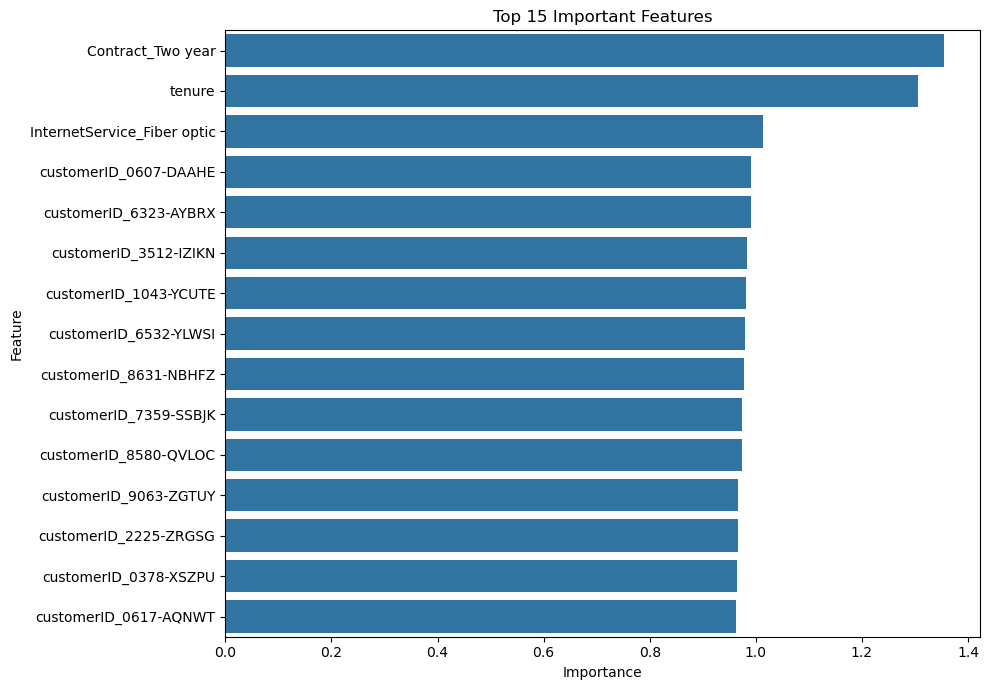

In [10]:
plt.figure(figsize=(10,7))

sns.barplot(
    data=top15,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.tight_layout()

plt.show()

In [11]:
positive = importance.sort_values(
    by="Coefficient",
    ascending=False
).head(10)

negative = importance.sort_values(
    by="Coefficient"
).head(10)

positive

,Feature,Coefficient,Importance
7041,InternetService_Fiber optic,1.012852,1.012852
411,customerID_0607-DAAHE,0.991264,0.991264
4474,customerID_6323-AYBRX,0.991237,0.991237
2450,customerID_3512-IZIKN,0.983999,0.983999
711,customerID_1043-YCUTE,0.981147,0.981147
4624,customerID_6532-YLWSI,0.979868,0.979868
6086,customerID_8631-NBHFZ,0.978354,0.978354
5222,customerID_7359-SSBJK,0.973556,0.973556
6047,customerID_8580-QVLOC,0.973090,0.973090
6391,customerID_9063-ZGTUY,0.966998,0.966998


In [12]:
negative

,Feature,Coefficient,Importance
7056,Contract_Two year,-1.354769,1.354769
1,tenure,-1.306107,1.306107
7055,Contract_One year,-0.759179,0.759179
1747,customerID_2545-EBUPK,-0.703596,0.703596
4699,customerID_6630-UJZMY,-0.689795,0.689795
5788,customerID_8161-QYMTT,-0.681720,0.681720
4497,customerID_6350-XFYGW,-0.679078,0.679078
3461,customerID_4912-PIGUY,-0.674812,0.674812
2320,customerID_3320-VEOYC,-0.674003,0.674003
20,customerID_0021-IKXGC,-0.672495,0.672495


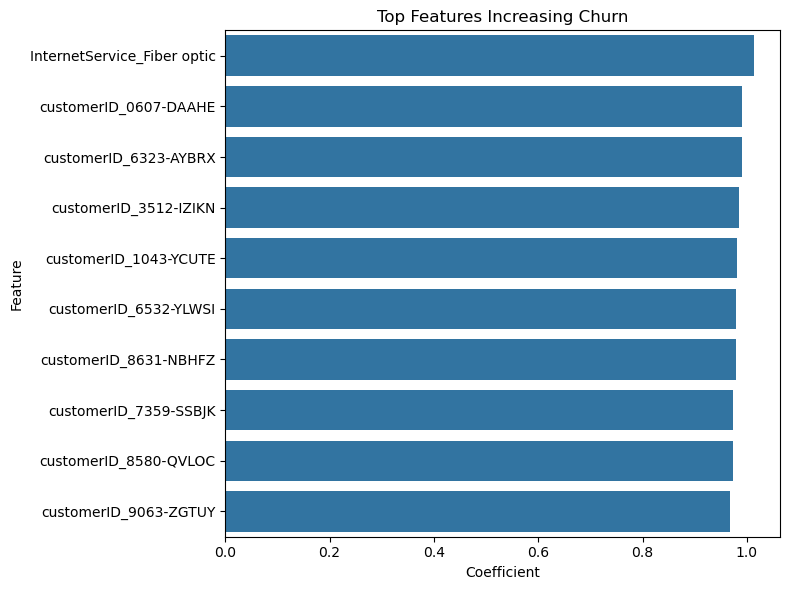

In [13]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=positive,
    x="Coefficient",
    y="Feature"
)

plt.title("Top Features Increasing Churn")

plt.tight_layout()

plt.show()

# Business Interpretation

Positive coefficients increase the probability of customer churn.

Negative coefficients reduce churn probability.

Business teams should focus on reducing the risk associated with the strongest positive features.

In [14]:
top10 = importance.head(10)

for i, row in top10.iterrows():
    print(f"{row['Feature']}  -->  {row['Coefficient']:.4f}")

Contract_Two year  -->  -1.3548
tenure  -->  -1.3061
InternetService_Fiber optic  -->  1.0129
customerID_0607-DAAHE  -->  0.9913
customerID_6323-AYBRX  -->  0.9912
customerID_3512-IZIKN  -->  0.9840
customerID_1043-YCUTE  -->  0.9811
customerID_6532-YLWSI  -->  0.9799
customerID_8631-NBHFZ  -->  0.9784
customerID_7359-SSBJK  -->  0.9736


In [15]:
summary = importance.head(20)

summary

,Feature,Coefficient,Importance
7056,Contract_Two year,-1.354769,1.354769
1,tenure,-1.306107,1.306107
7041,InternetService_Fiber optic,1.012852,1.012852
411,customerID_0607-DAAHE,0.991264,0.991264
4474,customerID_6323-AYBRX,0.991237,0.991237
2450,customerID_3512-IZIKN,0.983999,0.983999
711,customerID_1043-YCUTE,0.981147,0.981147
4624,customerID_6532-YLWSI,0.979868,0.979868
6086,customerID_8631-NBHFZ,0.978354,0.978354
5222,customerID_7359-SSBJK,0.973556,0.973556


In [16]:
summary.to_csv(
    "../data/top20_features.csv",
    index=False
)

print("Top 20 Features Saved!")

Top 20 Features Saved!


# Conclusion

The Logistic Regression coefficients clearly identify which customer characteristics influence churn the most.

These insights can help:

- Marketing Team
- Customer Retention Team
- Sales Team
- Management

take proactive actions to reduce churn.